<div align="center">

# Data Plotting

</div>


### Import Essential functions

In [21]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 

### Import data

In [22]:
# Load Excel file
df = pd.read_excel("Well data_Section_8_Run_1.xlsx", sheet_name="Raw_Data")

In [23]:
#Show header
df.head()

,Date and Time,Hole_Depth,Bit_Status,Bit_Position,ASM1_TVD,ASM1_EMW,ASM2_TVD,ASM2_EMW,ASM3_TVD,ASM3_EMW,...,Pump_Press,ROP_Ave,Rotary_RPM,Rotary_Torque,Standpipe_Press_1,Standpipe_Press_2,Top_Drive_RPM,Top_Drive_Torque,TVD_1,TVD_2
0,2018-06-11 06:00:00,2336.0,0.0,12.02,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,...,0.98,-999.25,-999.25,-999.25,-999.25,-999.25,0.0,0.0,1936.01,-999.25
1,2018-06-11 06:00:02,2336.0,0.0,12.02,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,...,0.98,-999.25,-999.25,-999.25,-999.25,-999.25,0.0,0.0,1936.01,-999.25
2,2018-06-11 06:00:04,2336.0,0.0,12.02,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,...,0.98,-999.25,-999.25,-999.25,-999.25,-999.25,0.0,0.0,1936.01,-999.25
3,2018-06-11 06:00:06,2336.0,0.0,12.02,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,...,0.98,-999.25,-999.25,-999.25,-999.25,-999.25,0.0,0.0,1936.01,-999.25
4,2018-06-11 06:00:08,2336.0,0.0,12.02,-999.25,-999.25,-999.25,-999.25,-999.25,-999.25,...,0.98,-999.25,-999.25,-999.25,-999.25,-999.25,0.0,0.0,1936.01,-999.25


In [24]:
df[["Standpipe_Press_1", "Standpipe_Press_2", "Pump_Press", "Flow_In_Rate"]].describe()
df[["Standpipe_Press_1", "Standpipe_Press_2", "Pump_Press", "Flow_In_Rate"]].nunique()

Standpipe_Press_1        1
Standpipe_Press_2        1
Pump_Press           15425
Flow_In_Rate           104
dtype: int64

In [25]:
df["Date and Time"] = pd.to_datetime(df["Date and Time"])

columns_needed = [
    "Date and Time",
    "Pump_Press",              # SPP
    "Flow_In_Rate"
]

df_selected = df[columns_needed]
df_selected.head()

,Date and Time,Pump_Press,Flow_In_Rate
0,2018-06-11 06:00:00,0.98,0.0
1,2018-06-11 06:00:02,0.98,0.0
2,2018-06-11 06:00:04,0.98,0.0
3,2018-06-11 06:00:06,0.98,0.0
4,2018-06-11 06:00:08,0.98,0.0


### Step 1: Plotting

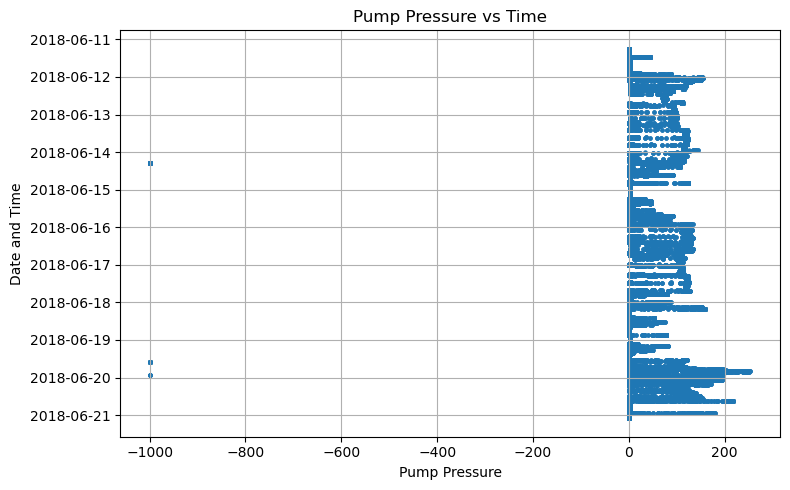

In [26]:
plt.figure(figsize=(8, 5))
plt.scatter(df_selected["Pump_Press"], df_selected["Date and Time"], s=5)
plt.gca().invert_yaxis()

plt.xlabel("Pump Pressure")
plt.ylabel("Date and Time")
plt.title("Pump Pressure vs Time")
plt.grid(True)
plt.tight_layout()
#plt.savefig("pump_pressure_vs_time.pdf")
plt.show()


### Step 2: Data Cleaning

In [27]:
print("Before cleaning:", len(df_selected))

df_selected = df_selected.dropna() #Remove coloumns that have 1 or more empty rows (NaN rows)
df_selected = df_selected[df_selected["Flow_In_Rate"] > 0]  # keep circulation only
df_selected = df_selected[df_selected["Pump_Press"] > 0] # Remove all values that are less than 0

print("After cleaning:", len(df_selected))

Before cleaning: 424800
After cleaning: 234606


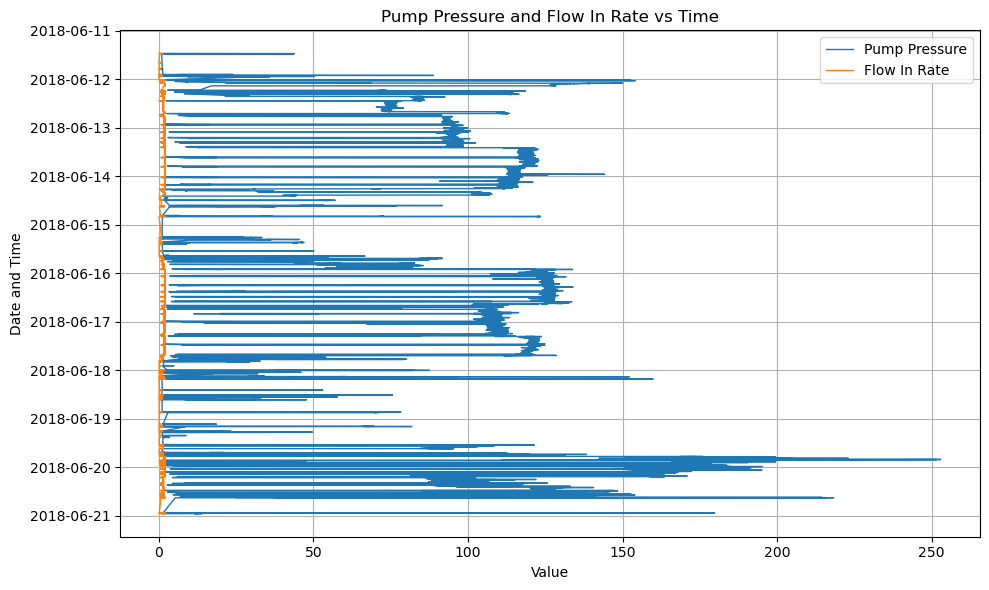

In [28]:
plt.figure(figsize=(10, 6))

# Plot Pump Pressure vs Time
plt.plot(df_selected["Pump_Press"], df_selected["Date and Time"], label="Pump Pressure", linewidth=1)

# Plot Flow In Rate vs Time
plt.plot(df_selected["Flow_In_Rate"], df_selected["Date and Time"], label="Flow In Rate", linewidth=1)

plt.gca().invert_yaxis()
plt.xlabel("Value")
plt.ylabel("Date and Time")
plt.title("Pump Pressure and Flow In Rate vs Time")
plt.legend()
plt.grid(True)
plt.tight_layout()

#plt.savefig("pump_and_flow_vs_time.pdf")
plt.show()


### Step 3: Identyfing losses

In [29]:
df_selected["Date"] = df_selected["Date and Time"].dt.date
unique_days = df_selected["Date"].unique()
unique_days

array([datetime.date(2018, 6, 11), datetime.date(2018, 6, 12),
       datetime.date(2018, 6, 13), datetime.date(2018, 6, 14),
       datetime.date(2018, 6, 15), datetime.date(2018, 6, 16),
       datetime.date(2018, 6, 17), datetime.date(2018, 6, 18),
       datetime.date(2018, 6, 19), datetime.date(2018, 6, 20)],
      dtype=object)

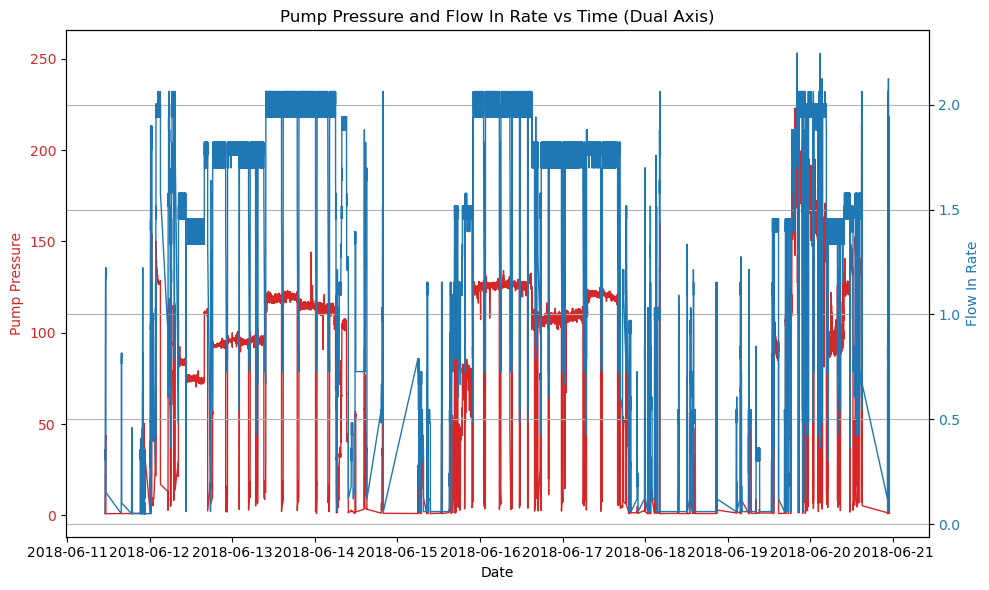

In [32]:
fig, ax1 = plt.subplots(figsize=(10,6))

#Pump Pressure
ax1.plot(df_selected["Date and Time"], df_selected["Pump_Press"],
         color="tab:red", label="Pump Pressure", linewidth=1)
ax1.set_xlabel("Date")
ax1.set_ylabel("Pump Pressure", color="tab:red")
ax1.tick_params(axis='y', labelcolor="tab:red")

#Flow In Rate
ax2 = ax1.twinx()
ax2.plot(df_selected["Date and Time"], df_selected["Flow_In_Rate"],
         color="tab:blue", label="Flow In Rate", linewidth=1)
ax2.set_ylabel("Flow In Rate", color="tab:blue")
ax2.tick_params(axis='y', labelcolor="tab:blue")

plt.title("Pump Pressure and Flow In Rate vs Time (Dual Axis)")
plt.grid(True)
plt.tight_layout()
#plt.savefig("pressure_flow_time_DA.pdf")
plt.show()


In [ ]:
for day in unique_days:
    df_day = df_selected[df_selected["Date"] == day]

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Pump Pressure
    ax1.plot(
        df_day["Date and Time"],
        df_day["Pump_Press"],
        color="red",
        label="Pump Pressure",
        linewidth=1
    )
    ax1.set_xlabel("Date and Time")
    ax1.set_ylabel("Pump Pressure", color="red")
    ax1.tick_params(axis='y', labelcolor="red")
    plt.setp(ax1.get_xticklabels(), rotation=30, ha="right")

    #Flow In Rate
    ax2 = ax1.twinx()
    ax2.plot(
        df_day["Date and Time"],
        df_day["Flow_In_Rate"],
        color="blue",
        label="Flow In Rate",
        linewidth=1,
        linestyle="--"
    )
    ax2.set_ylabel("Flow In Rate", color="blue")
    ax2.tick_params(axis='y', labelcolor="blue")

    plt.title(f"Pump Pressure and Flow In Rate vs Time — {day}")
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(f"pressure_flow_{day}.pdf")

    plt.show()
